Saving iris.jpg to iris (1).jpg


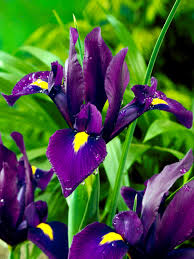

In [35]:
from google.colab import files
from IPython.display import Image, display

uploaded = files.upload()

display(Image(filename=list(uploaded.keys())[0], width=400))

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [38]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000  

In [39]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [40]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


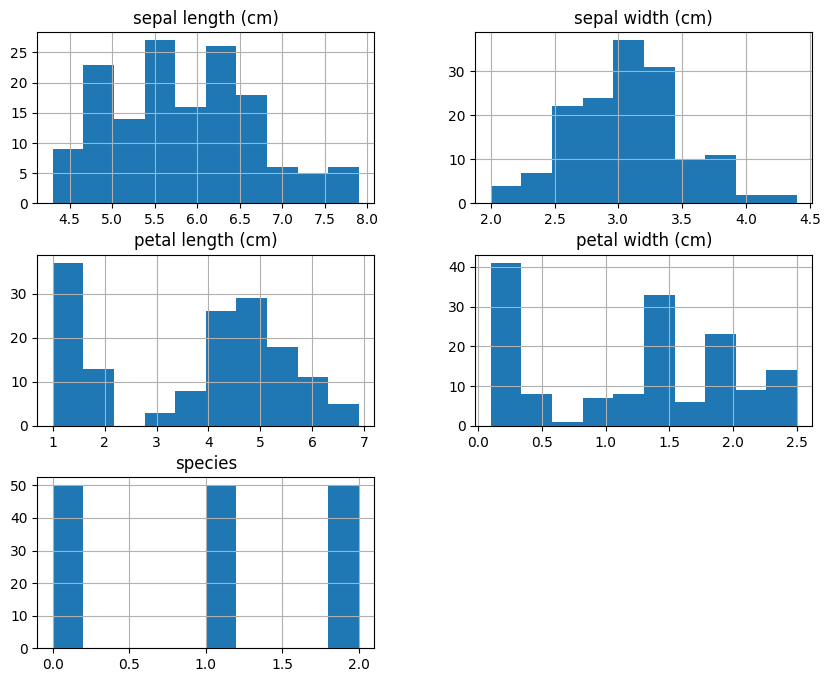

In [41]:
df.hist(figsize=(10,8))
plt.show()

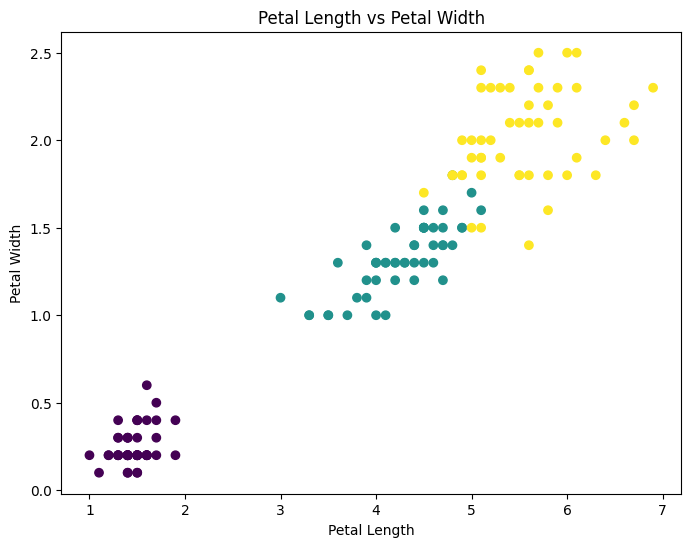

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)'],
    c=df['species']
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")

plt.show()

In [43]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


In [45]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [46]:
lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


In [47]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Logistic Regression"
    ],
    "Accuracy": [
        knn_accuracy,
        dt_accuracy,
        lr_accuracy
    ]
})

print(results)

                 Model  Accuracy
0                  KNN       1.0
1        Decision Tree       1.0
2  Logistic Regression       1.0


In [48]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [49]:
print(confusion_matrix(y_test, knn_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [50]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn.predict(sample)

print("Predicted Species:")
print(iris.target_names[prediction][0])

Predicted Species:
setosa


In [51]:
import joblib

joblib.dump(knn, "iris_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
